# Day-50(14July)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from sklearn import preprocessing
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [2]:
dset = pd.read_csv(r"C:\Users\sande\Downloads\car-mpg.csv")
dset.head(5)

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino


In [3]:
dset.isnull().sum()

mpg         0
cyl         0
disp        0
hp          0
wt          0
acc         0
yr          0
origin      0
car_type    0
car_name    0
dtype: int64

In [4]:
dset["origin"].unique()

array([1, 3, 2], dtype=int64)

- If we don’t replace origin values (1,3,2), ML model might think:
    - Asia (3) > Europe (2) > America (1) → which implies order or magnitude, which is incorrect

In [5]:
dset = dset.drop(["car_name"],axis=1)
dset["origin"] = dset["origin"].replace({1:"America",2:"Europe",3:"Asia"})
dset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   mpg       398 non-null    float64
 1   cyl       398 non-null    int64  
 2   disp      398 non-null    float64
 3   hp        398 non-null    object 
 4   wt        398 non-null    int64  
 5   acc       398 non-null    float64
 6   yr        398 non-null    int64  
 7   origin    398 non-null    object 
 8   car_type  398 non-null    int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


- we use `get_dummies()` to convert them into one-hot encoded columns suitable for machine learning models.

In [6]:
dset = pd.get_dummies(dset,columns=["origin"],dtype=int)
dset = dset.replace("?",np.nan)

In [7]:
# To Numeric 
dset = dset.apply(pd.to_numeric, errors="coerce")

numeric_cols = dset.select_dtypes(include=[np.number]).columns
dset[numeric_cols] = dset[numeric_cols].apply(lambda x: x.fillna(x.median()))

In [8]:
dset.head(5)

,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_America,origin_Asia,origin_Europe
0,18.0,8,307.0,130.0,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,0,1,0,0


### Features and Target variable Seperation

In [9]:
x= dset.drop(["mpg"],axis=1)
y= dset[["mpg"]]

In [10]:
x_s = preprocessing.scale(x)
x_s = pd.DataFrame(x_s, columns = x.columns)

y_s = preprocessing.scale(y)
y_s = pd.DataFrame(y_s, columns = y.columns)

In [11]:
x_s

,cyl,disp,hp,wt,acc,yr,car_type,origin_America,origin_Asia,origin_Europe
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
...,...,...,...,...,...,...,...,...,...,...
393,-0.856321,-0.513026,-0.479482,-0.213324,0.011586,1.621983,0.941412,0.773559,-0.497643,-0.461968
394,-0.856321,-0.925936,-1.370127,-0.993671,3.279296,1.621983,0.941412,-1.292726,-0.497643,2.164651
395,-0.856321,-0.561039,-0.531873,-0.798585,-1.440730,1.621983,0.941412,0.773559,-0.497643,-0.461968
396,-0.856321,-0.705077,-0.662850,-0.408411,1.100822,1.621983,0.941412,0.773559,-0.497643,-0.461968


In [12]:
y_s

,mpg
0,-0.706439
1,-1.090751
2,-0.706439
3,-0.962647
4,-0.834543
...,...
393,0.446497
394,2.624265
395,1.087017
396,0.574601


In [13]:
x_train,x_test,y_train,y_test = train_test_split(x_s,y_s,test_size=0.2,random_state=0)

In [14]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

for idx, col_name in enumerate(x_train.columns):
    print(f"The coef for {col_name} is {regressor.coef_[0][idx]}")
intercept = regressor.intercept_[0]
print(f"The intercept is {intercept}")

The coef for cyl is 0.24638776053571607
The coef for disp is 0.29177092098664514
The coef for hp is -0.18081621820393654
The coef for wt is -0.6675530609868133
The coef for acc is 0.06537309205777078
The coef for yr is 0.348177025942672
The coef for car_type is 0.3339231253960362
The coef for origin_America is -0.08117984631927024
The coef for origin_Asia is 0.06986098209664919
The coef for origin_Europe is 0.030003161242288134
The intercept is -0.018006831370923248


### Lasso Regression (L1 Regularization)

In [15]:
lmodel = Lasso(alpha=0.1)
lmodel.fit(x_train, y_train)
print("Lasso model coefficients:\n", lmodel.coef_)

Lasso model coefficients:
 [-0.         -0.         -0.07247557 -0.45867691  0.          0.2698134
  0.11341188 -0.04988145  0.          0.        ]


### Redge Regression (L2 Regularization)

In [16]:
rmodel = Ridge(alpha=0.3)
rmodel.fit(x_train,y_train)
print(f"Ridge Model Coef is \n {rmodel.coef_}")

Ridge Model Coef is 
 [[ 0.24342352  0.28293268 -0.18074242 -0.65967997  0.06398366  0.34745486
   0.33096428 -0.08087356  0.06988696  0.0295866 ]]


In [17]:
print("Simple Linear Model")
print(regressor.score(x_train, y_train))
print(regressor.score(x_test, y_test))
print("Ridge")
print(rmodel.score(x_train, y_train))
print(rmodel.score(x_test, y_test))
print("Lasso")
print(lmodel.score(x_train, y_train))
print(lmodel.score(x_test, y_test))

Simple Linear Model
0.8373422857977738
0.8474768646673948
Ridge
0.837332956087454
0.847263786646594
Lasso
0.8007202116330951
0.8283046020148332


### Model Parameter Tuning
*  $R^2$ is not a reliable metric as it `always increases` with addition of `more attributes` even if the attributes have `no influence` on the predicted variable. Instead we use $adjusted R^2$ which removes the statistical chance that improves $R^2$ 

$adjusted r^2 = r^2 - fluke$
* Scikit does not provide a facility for $adjustedR^2$ so we use statsmodel, a library that gives results similar to what you obtain in R language
* This library expects the X and Y to be given in one single dataframe

In [18]:
data_train_test = pd.concat([x_train, y_train], axis =1)
data_train_test.head()

,cyl,disp,hp,wt,acc,yr,car_type,origin_America,origin_Asia,origin_Europe,mpg
64,1.498191,1.196232,1.197027,1.376929,-0.750880,-1.085858,-1.062235,0.773559,-0.497643,-0.461968,-1.090751
55,-0.856321,-0.925936,-1.160564,-1.343645,1.246054,-1.356642,0.941412,-1.292726,-0.497643,2.164651,0.446497
317,-0.856321,-0.925936,-0.689046,-0.925095,0.084201,1.080415,0.941412,-1.292726,-0.497643,2.164651,1.381656
102,-0.856321,-0.925936,-1.527300,-1.206493,1.972212,-0.815074,0.941412,-1.292726,-0.497643,2.164651,0.318393
358,-0.856321,-0.705077,-0.793827,-0.396587,0.991899,1.351199,0.941412,-1.292726,2.009471,-0.461968,1.035775


In [19]:
# Fit OLS regression model
ols1 = smf.ols(formula='mpg ~ cyl+disp+hp+wt+acc+yr+car_type+origin_America+origin_Europe+origin_Asia', data=data_train_test).fit()

# View summary
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     176.2
Date:                Thu, 17 Jul 2025   Prob (F-statistic):          7.60e-116
Time:                        21:51:44   Log-Likelihood:                -160.75
No. Observations:                 318   AIC:                             341.5
Df Residuals:                     308   BIC:                             379.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0180      0.023     -0.

<Axes: xlabel='acc', ylabel='mpg'>

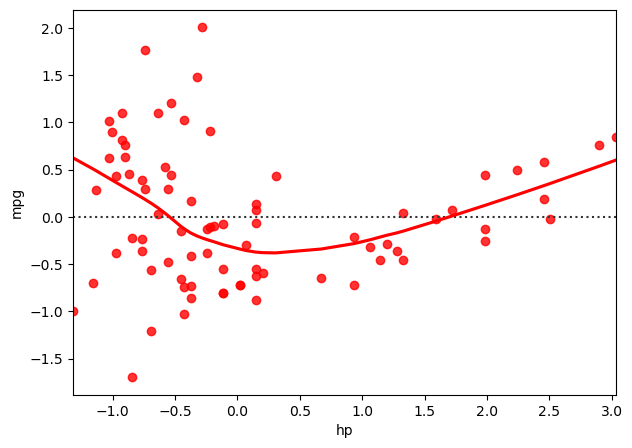

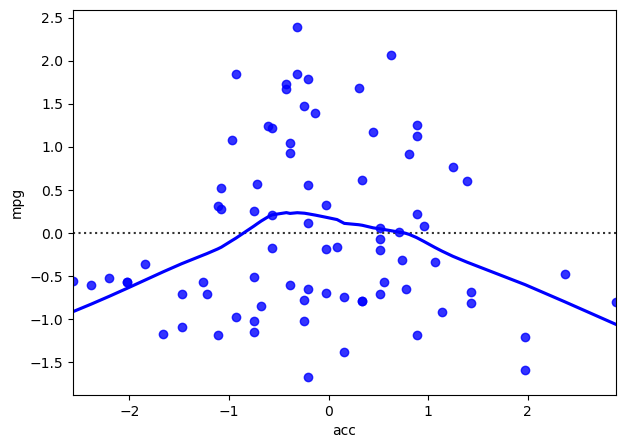

In [30]:
fig = plt.figure(figsize=(7,5))
sns.residplot(x= x_test['hp'], y= y_test['mpg'], color='red', lowess=True )

fig = plt.figure(figsize=(7,5))
sns.residplot(x= x_test['acc'], y= y_test['mpg'], color='blue', lowess=True )